<a href="https://colab.research.google.com/github/Divya030806/DataScience/blob/main/Copy_of_DSassignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
trades=pd.read_csv("historical_data.csv")
fear_greed=pd.read_csv("fear_greed.csv")

In [5]:
print(trades.head())
print(fear_greed.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [6]:
print(trades.columns)
print(fear_greed.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [7]:
trades['Date'] = pd.to_datetime(trades['Timestamp']).dt.normalize()

fear_greed['Date'] = pd.to_datetime(fear_greed['date']).dt.normalize()

In [8]:
print(trades['Timestamp'].head())

print(fear_greed['date'].head())

print(trades['Timestamp'].dtype)

print(fear_greed['date'].dtype)

0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object
float64
object


In [9]:
print(trades['Timestamp'].min())
print(trades['Timestamp'].max())

print(fear_greed['date'].min())
print(fear_greed['date'].max())

1680000000000.0
1750000000000.0
2018-02-01
2025-05-02


In [10]:
trades['Date'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
).dt.strftime('%Y-%m-%d')

In [11]:
fear_greed['Date'] = pd.to_datetime(
    fear_greed['date']
).dt.strftime('%Y-%m-%d')

In [12]:
common_dates = set(trades['Date']) & set(fear_greed['Date'])

print("Common dates:", len(common_dates))

Common dates: 479


In [13]:
merged = pd.merge(
    trades,
    fear_greed[['Date', 'classification', 'value']],
    on='Date',
    how='left'
)

In [14]:
print(merged.shape)

print(merged['classification'].value_counts())

(211224, 19)
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [20]:

print(trades['Date'].min(), trades['Date'].max())
print(fear_greed['Date'].min(), fear_greed['Date'].max())
print("Common dates:", len(set(trades['Date']) & set(fear_greed['Date'])))

2023-05-01 2025-05-01
2018-02-01 2025-05-02
Common dates: 479


In [15]:
## Analysis-1-Average profit by Sentiment
analysis1 = merged.groupby('classification')['Closed PnL'].mean()

print(analysis1)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


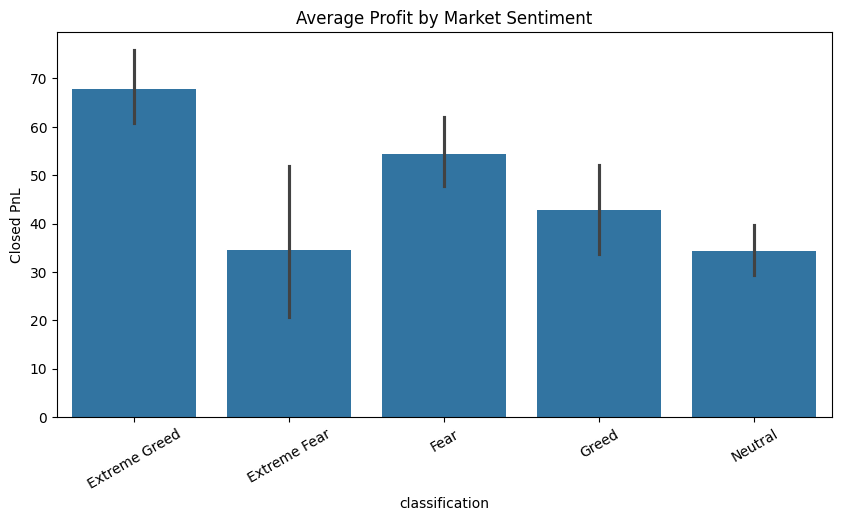

In [17]:
## Graph-1
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.barplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.title('Average Profit by Market Sentiment')
plt.xticks(rotation=30)
plt.show()

In [21]:
## Analysis-2-Number of Trades
trade_count = merged.groupby(
    'classification'
).size()

print(trade_count)

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


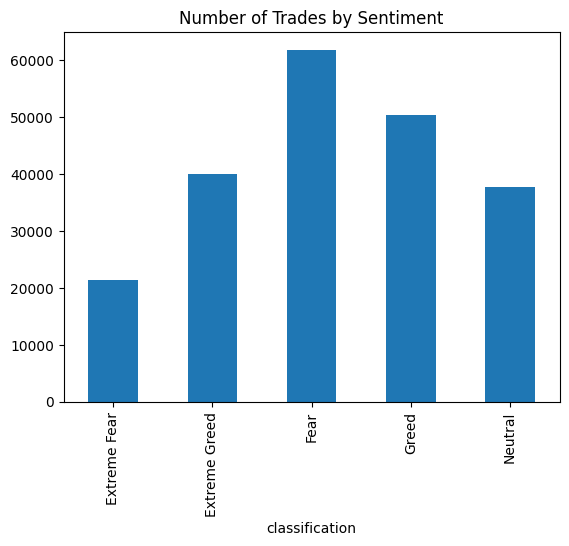

In [22]:
## Grappg-2
trade_count.plot(kind='bar')

plt.title("Number of Trades by Sentiment")
plt.show()

In [23]:
## Analysis-3-Buy vs Sell
buy_sell = pd.crosstab(
    merged['classification'],
    merged['Side']
)

print(buy_sell)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


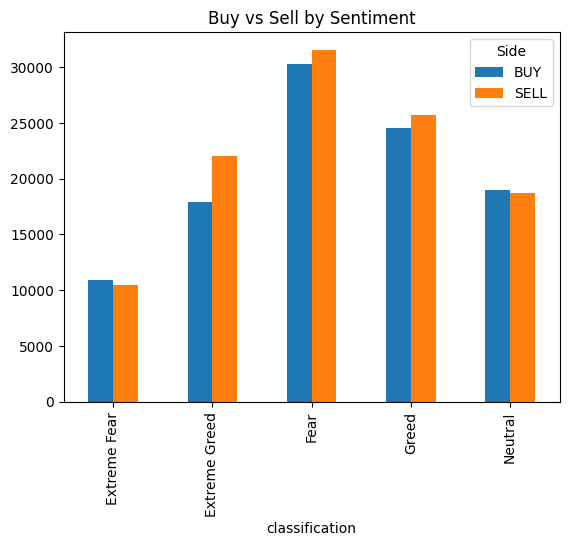

In [24]:
## Graph-3
buy_sell.plot(kind='bar')

plt.title("Buy vs Sell by Sentiment")
plt.show()

In [27]:
## Analysis-4-Top Traders
top_traders = merged.groupby(
    'Account'
)['Closed PnL'].sum().sort_values(
    ascending=False
)

print(top_traders.head(10))

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64
